In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [28]:
#Load Dataset
df = pd.read_csv(r"C:\Users\user\Downloads\Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [29]:
#Data Cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


In [30]:
#Convert Target Variable
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

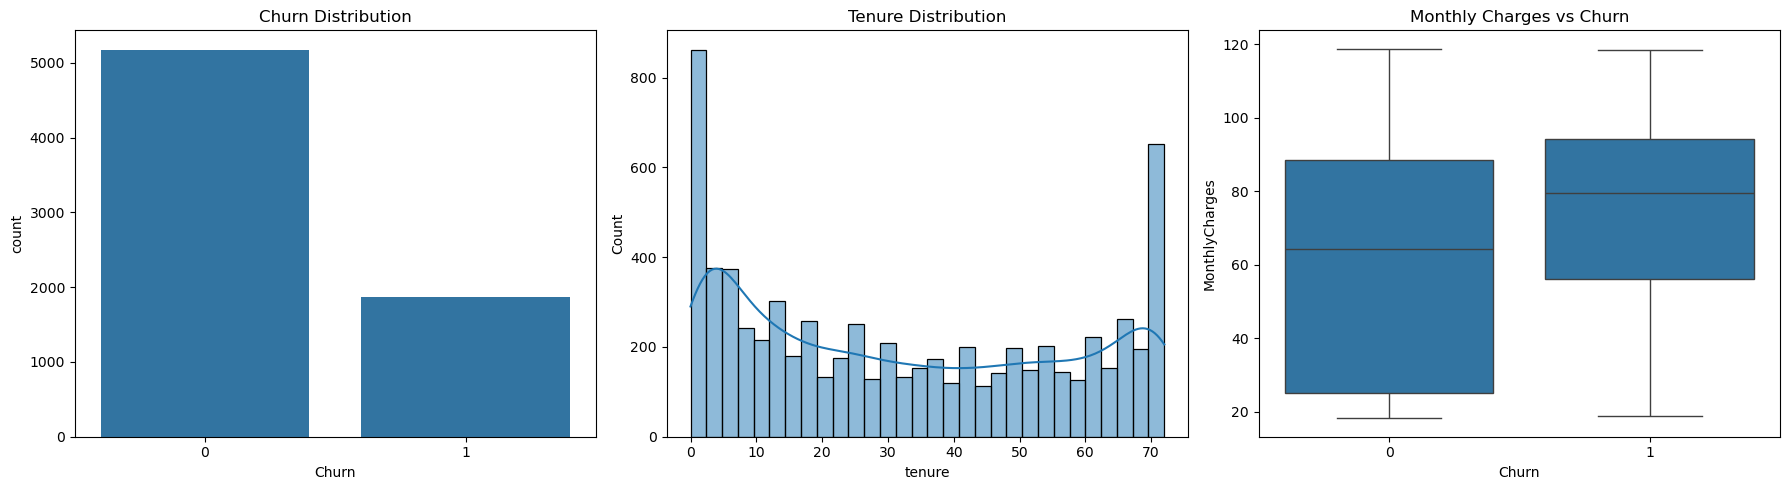

In [31]:
#EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x="Churn", data=df, ax=axes[0])
axes[0].set_title("Churn Distribution")

sns.histplot(df["tenure"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Tenure Distribution")

sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[2])
axes[2].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

In [32]:
# Feature engeneering and encoding
df["AvgMonthlyCharges"] = df["TotalCharges"] / (df["tenure"] + 1)

X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

In [35]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test = scaler.transform(X_test)

In [37]:
#Train Logistic Regression
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [38]:
#Prediction
y_pred = model.predict(X_test)
print(y_pred)

[0 1 0 ... 0 0 0]


In [39]:
#Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.808374733853797
Precision: 0.674496644295302
Recall: 0.5374331550802139
F1 Score: 0.5982142857142857
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



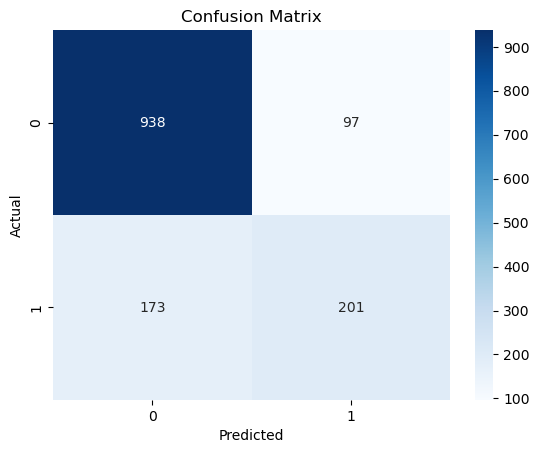

In [40]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

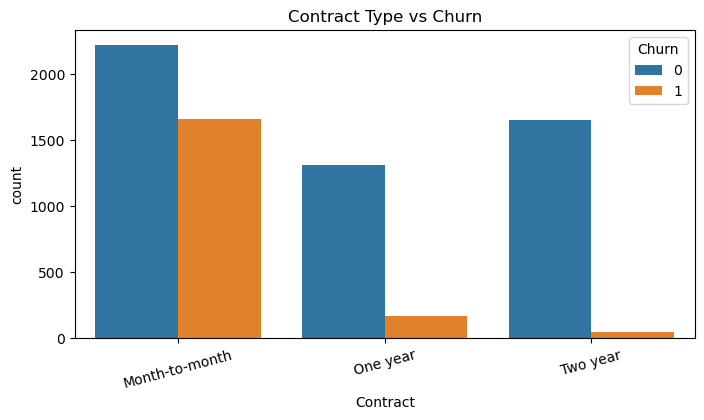

In [41]:
plt.figure(figsize=(8,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

## Conclusion
The model was able to predict customer churn using customer service and billing information. The analysis showed that churn is related to tenure and monthly charges. This model can help the company identify customers at risk of leaving and take action early.